In [1]:
using GenLAProblems, LinearAlgebra, RowEchelon, Latexify, LaTeXStrings, Random;

<div style="float:center;width:100%;text-align:center;">
<strong style="height:100px;color:darkred;font-size:40px;">Problem Review</strong>
</div>

# 1. GE/GJ Problems

## 1.1 Gaussian Elimination (GE), Gauss-Jordan Elimination (GJ)

### 1.1.1  GE and Backsubstitution

#### **Consistent System**

In [2]:
M=3; N=5; r=3  # M is the number of rows, N the number of cols, r the number of pivots
# --------------------------------------------------------
A,X,B = gen_gj_pb(M,N,r; maxint=2, pivot_in_first_col=true, num_rhs=1,has_zeros=true)
pb_ge = ShowGe{Rational{Int}}( A,  B)
l_show( L"A =", A, L"\quad b=", B, inline=true)

L"$A = \left(\begin{array}{rrrrr}
2 & -2 & 0 & 4 & -2 \\
2 & -2 & 0 & 2 & -4 \\
0 & 0 & 0 & 0 & -1 \\
\end{array}\right) \quad b= \left(\begin{array}{r}
-6 \\
-8 \\
-2 \\
\end{array}\right)$
"

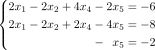

In [3]:
show_system( pb_ge, b_col=1, fig_scale=1.2 )

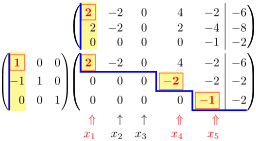

In [4]:
ref!(pb_ge, gj=false)               # perform gaussian elimination: gj=true for Gauss-Jordan Elimination
show_layout!(pb_ge, fig_scale=1.2)  # show the computational layout

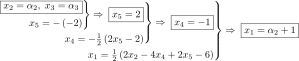

In [5]:
show_backsubstitution!(pb_ge, b_col=1)

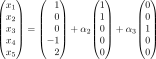

In [6]:
show_solution!(pb_ge, b_col=1)

In [7]:
Xp, Xh = solutions(pb_ge)
l_show( L"B =", pb_ge.B, L"\quad x_p =", Xp, L"\quad x_h = ", Xh)

L"$B = \left(\begin{array}{r}
-6 \\
-8 \\
-2 \\
\end{array}\right) \quad x_p = \left(\begin{array}{r}
1 \\
0 \\
0 \\
-1 \\
2 \\
\end{array}\right) \quad x_h = \left(\begin{array}{rr}
1 & 0 \\
1 & 0 \\
0 & 1 \\
0 & 0 \\
0 & 0 \\
\end{array}\right)$
"

In [8]:
# check the solution
@show pb_ge.A * Xp == pb_ge.B;

pb_ge.A * Xp == pb_ge.B = true


In [9]:
display( pr( "Details of the computations are kept in the ShowGE{} structure"; color=:blue, sz=20, height=25 ))
for name in fieldnames(typeof(pb_ge))
  if isdefined(pb_ge, name)
     if name == :desc || name == :h
          println(name, " ... ")
      else
          println(name, " = ", getfield(pb_ge, name))
      end
  else
      println(name, " = <undef>")
  end
end

LAlatex.HTMLOut("<div style=\"font-size: 20px; color: blue; text-align: left; height: 25px; width: 100%;\">\n  <p>Details of the computations are kept in the ShowGE{} structure</p>\n</div>\n")

tmp_dir = tmp
keep_file = tmp/show_layout
A = Rational{Int64}[2 -2 0 4 -2; 2 -2 0 2 -4; 0 0 0 0 -1]
B = Rational{Int64}[-6; -8; -2;;]
num_rhs = 1
normal_eq = false
matrices = Vector{Union{Nothing, Matrix{Rational{Int64}}}}[[nothing, Rational{Int64}[2 -2 0 4 -2 -6; 2 -2 0 2 -4 -8; 0 0 0 0 -1 -2]], [Rational{Int64}[1 0 0; -1 1 0; 0 0 1], Rational{Int64}[2 -2 0 4 -2 -6; 0 0 0 -2 -2 -2; 0 0 0 0 -1 -2]]]
cascade = <undef>
pivot_cols = [1, 4, 5]
free_cols = [2, 3]
desc ... 
pivot_list = Vector{Any}[[(1, 1), [(0, 0), (1, 3), (2, 4)]], [(0, 1), [(0, 0)]], [(1, 0), [(0, 0)]]]
bg_for_entries = Vector[Any[1, 1, [(0, 0), (1, 3), (2, 4)], "yellow!40"], Vector{Any}[[0, 1, [(0, 0)], "yellow!40"], [0, 1, Any[(0, 0), [(0, 0), (2, 0)]], "yellow!40", 1]], Any[1, 0, Any[(0, 0), [(0, 0), (2, 0)]], "yellow!40", 1]]
ref_path_list = Vector{Any}[[1, 1, [(0, 0), (1, 3), (2, 4)], "vh", "blue,line width=0.5mm"], [0, 1, [(0, 0)], "vv", "blue,line width=0.5mm"], [1, 0, [(0, 0)], "vv", "blue,line width=0.5mm"]]
basi

#### **Inconsistent System**

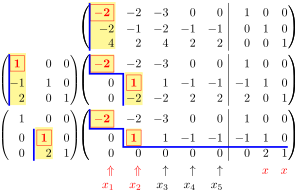

In [10]:
Random.seed!(4562)
A,X,B = gen_gj_pb(3,5,2; maxint=2, pivot_in_first_col=true, num_rhs=0,has_zeros=true)
pb_x = ShowGe{Rational{Int}}( A,  Matrix(one(eltype(A))I(M)))
ref!(pb_x, gj=false)               # perform gaussian elimination
display(show_layout!(pb_x, fig_scale=1.2))  # show the computational layout

In [11]:
display(show_backsubstitution!(pb_x, b_col=3))

In [12]:
display(show_solution!(pb_x, b_col=3))

Rational{Int64}[]

In [13]:
Xp, Xh = solutions(pb_x)
display(l_show( L"B =", pb_x.B, L"\quad x_p =", Xp, L"\quad x_h = ", Xh))

L"$B = \left(\begin{array}{rrr}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1 \\
\end{array}\right) \quad x_p = \frac{1}{2} \left(\begin{array}{r}
1 \\
-2 \\
0 \\
0 \\
0 \\
\end{array}\right) \quad x_h = \frac{1}{2} \left(\begin{array}{rrr}
-1 & -2 & -2 \\
-2 & 2 & 2 \\
2 & 0 & 0 \\
0 & 2 & 0 \\
0 & 0 & 2 \\
\end{array}\right)$
"

In [14]:
pb_x.rhs_consistent

LoadError: type ShowGe has no field rhs_consistent

In [36]:
display( pr( "Details of the computations are kept in the ShowGE{} structure"; color=:blue, sz=20, height=25 ))
for name in fieldnames(typeof(pb_x))
  if isdefined(pb_x, name)
     if name == :desc || name == :h
          println(name, " ... ")
      else
          println(name, " = ", getfield(pb_x, name))
      end
  else
      println(name, " = <undef>")
  end
end

LAlatex.HTMLOut("<div style=\"font-size: 20px; color: blue; text-align: left; height: 25px; width: 100%;\">\n  <p>Details of the computations are kept in the ShowGE{} structure</p>\n</div>\n")

tmp_dir = tmp
keep_file = tmp/show_layout
A = Rational{Int64}[-2 -2 -3 0 0; -2 -1 -2 -1 -1; 4 2 4 2 2]
B = Rational{Int64}[1 0 0; 0 1 0; 0 0 1]
num_rhs = 3
normal_eq = false
matrices = Vector{Union{Nothing, Matrix{Rational{Int64}}}}[[nothing, Rational{Int64}[-2 -2 -3 0 0 1 0 0; -2 -1 -2 -1 -1 0 1 0; 4 2 4 2 2 0 0 1]], [Rational{Int64}[1 0 0; -1 1 0; 2 0 1], Rational{Int64}[-2 -2 -3 0 0 1 0 0; 0 1 1 -1 -1 -1 1 0; 0 -2 -2 2 2 2 0 1]], [Rational{Int64}[1 0 0; 0 1 0; 0 2 1], Rational{Int64}[-2 -2 -3 0 0 1 0 0; 0 1 1 -1 -1 -1 1 0; 0 0 0 0 0 0 2 1]]]
cascade = <undef>
pivot_cols = [1, 2]
free_cols = [3, 4, 5]
desc ... 
pivot_list = Vector{Any}[[(1, 1), [(0, 0), (1, 1)]], [(2, 0), [(1, 1)]], [(0, 1), [(0, 0)]], [(2, 1), [(0, 0), (1, 1)]], [(1, 0), [(0, 0)]]]
bg_for_entries = Vector[Vector{Any}[[1, 1, [(0, 0), (1, 1)], "yellow!40"], [1, 1, Any[(1, 1), [(1, 1), (2, 1)]], "yellow!40", 1]], Any[2, 0, Any[(1, 1), [(1, 1), (2, 1)]], "yellow!40", 1], Vector{Any}[[0, 1, [(0, 0)], "yellow!40"], [0, 1,

### 1.1.2 Inverses

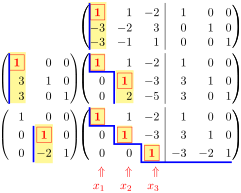

In [37]:
A, A_inv  = gen_inv_pb(3, maxint=3)
pb_inv    = ShowGe{Rational{Int}}( A,  Matrix(one(eltype(A))I(M)))
ref!(pb_inv, gj=true)
display(show_layout!(pb_inv, fig_scale=1.2))

In [38]:
l_show( L"A^{-1} =",  pb_inv.status == :consistent ? rhs_block(pb_inv) : "does not exist")

LoadError: UndefVarError: `rhs_block` not defined

## 1.2 Special Case Normal Equation

In [39]:
M=3; N=4; r=2
A,X,B = gen_gj_pb(M,N,r; maxint=2, pivot_in_first_col=true, num_rhs=1,has_zeros=true)
pb_least_squares = ShowGe{Rational{Int}}( A, B)
l_show( L"A =", A, L"\quad b=", B, inline=true)

L"$A = \left(\begin{array}{rrrr}
2 & 2 & -1 & -1 \\
0 & 0 & 1 & -1 \\
0 & 0 & 2 & -2 \\
\end{array}\right) \quad b= \left(\begin{array}{r}
2 \\
0 \\
0 \\
\end{array}\right)$
"

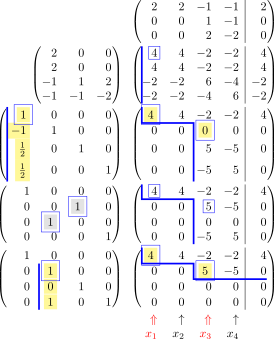

In [40]:
ref!(pb_least_squares, normal_eq=true)
show_layout!(pb_least_squares, fig_scale=1.2)

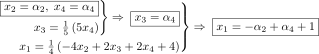

In [41]:
show_backsubstitution!(pb_least_squares, fig_scale=1.2)

## 1.3 LU and PLU

L"$\left(\begin{array}{rrrrrr}
-3 & -9 & 6 & 6 & 0 & 6 \\
9 & 27 & -18 & -17 & 0 & -20 \\
0 & 0 & 0 & -2 & 0 & 3 \\
0 & 0 & 0 & 0 & 0 & -1 \\
\end{array}\right) \ x = \left(\begin{array}{r}
15 \\
-41 \\
-7 \\
1 \\
\end{array}\right)$
"

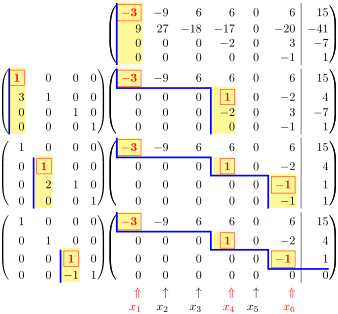

In [42]:
Random.seed!(5003)
m,n,r=4,6,3
pivot_cols, L, U, A = gen_lu_pb(m,n,r, maxint=3)
x,b                 = gen_rhs(A, pivot_cols)
display(l_show( A, L"\ x = ", b ))
pb_lu = ShowGe{Rational{Int}}( A,  b)
ref!(pb_lu, gj=false)               # perform gaussian elimination: gj=true for Gauss-Jordan Elimination
show_layout!(pb_lu, fig_scale=1.2)  # show the computational layout

In [43]:
function inv_list( pb )
    left_mats = [inv(row[1]) for row in pb.matrices if row[1] !== nothing]
end

display(l_show( "No row exchanges, L = ", L"E_1^{-1} E_2^{-1} E_3^{-1} = ", inv_list(pb_lu)... ))
display( l_show("A = L U = ", L, U ))

L"$\text{No row exchanges, L = } E_1^{-1} E_2^{-1} E_3^{-1} = \left(\begin{array}{rrrr}
1 & 0 & 0 & 0 \\
-3 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
\end{array}\right) \left(\begin{array}{rrrr}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & -2 & 1 & 0 \\
0 & 0 & 0 & 1 \\
\end{array}\right) \left(\begin{array}{rrrr}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 1 & 1 \\
\end{array}\right)$
"

L"$\text{A = L U = } \left(\begin{array}{rrrr}
1 & 0 & 0 & 0 \\
-3 & 1 & 0 & 0 \\
0 & -2 & 1 & 0 \\
0 & 0 & 1 & 1 \\
\end{array}\right) \left(\begin{array}{rrrrrr}
-3 & -9 & 6 & 6 & 0 & 6 \\
0 & 0 & 0 & 1 & 0 & -2 \\
0 & 0 & 0 & 0 & 0 & -1 \\
0 & 0 & 0 & 0 & 0 & 0 \\
\end{array}\right)$
"

In [44]:
display(pr("<strong>Forward substitution:</strong> L y = b", color=:blue, sz=15, height=20))
display(l_show( "y = ", Int.(L\b), ", the final right hand side"))
display(pr("<strong>Backward subsitution then proceeds as before</strong>", color=:blue, sz=15, height=20))

LAlatex.HTMLOut("<div style=\"font-size: 15px; color: blue; text-align: left; height: 20px; width: 100%;\">\n  <p><strong>Forward substitution:</strong> L y = b</p>\n</div>\n")

L"$\text{y = } \left(\begin{array}{r}
15 \\
4 \\
1 \\
0 \\
\end{array}\right) \text{, the final right hand side}$
"

LAlatex.HTMLOut("<div style=\"font-size: 15px; color: blue; text-align: left; height: 20px; width: 100%;\">\n  <p><strong>Backward subsitution then proceeds as before</strong></p>\n</div>\n")

# 2. QR

In [45]:
#A = gen_qr_problem(4; maxint=2)
A = gen_qr_problem_3(maxint=2)
A = A[:,1:3]
l_show(L"A =", A, inline=true)

L"$A = \left(\begin{array}{rrr}
0 & 3 & 1 \\
2 & -4 & -2 \\
0 & -4 & 7 \\
\end{array}\right)$
"

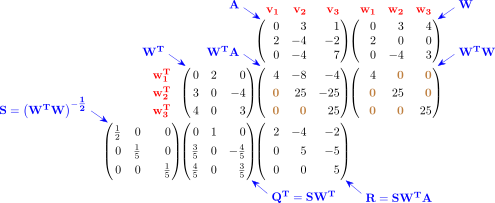

In [46]:
W   = gram_schmidt_w(A)
h,m = nM.gram_schmidt_qr(A, fig_scale=1.2, tmp_dir="tmp")
h

# 3. Eigenproblems

## 3.1 General Case

In [47]:
S,Λ,Sinv,A = gen_eigenproblem([-2,-2,0])
d,intA     = factor_out_denominator(A)

l_show( L"A = ", A, L"\qquad p(\lambda) = %$(charpoly(A))", inline=true )

L"$A = \left(\begin{array}{rrr}
10 & 12 & -6 \\
-4 & -6 & 2 \\
12 & 12 & -8 \\
\end{array}\right) \qquad p(\lambda) = -λ^3 - 4*λ^2 - 4*λ$
"

In [48]:
svg,spec = nM.show_eig_tbl(intA,Ascale=d, fig_scale=1.4, tmp_dir="tmp" )

(GenLAProblems.SVGOut("<svg\n   width=\"331.4375pt\"\n   height=\"181.9514pt\"\n   viewBox=\"-2.0 -2.0 331.4375 181.9514\"\n   version=\"1.2\"\n   id=\"svg351\"\n   sodipodi:docname=\"output.svg\"\n   xmlns:inkscape=\"http://www.inkscape.org/namespaces/inkscape\"\n   xmlns:sodipodi=\"http://sodipodi.sourceforge.net/DTD/sodipodi-0.dtd\"\n   xmlns:xlink=\"http://www.w3.org/1999/xlink\"\n   xmlns=\"http://www.w3.org/2000/svg\"\n   xmlns:svg=\"http://www.w3.org/2000/svg\">\n  <sodipodi:namedview\n     id=\"namedview353\"\n     pagecolor=\"#ffffff\"\n     bordercolor=\"#000000\"\n     borderopacity=\"0.25\"\n     inkscape:showpageshadow=\"2\"\n     inkscape:pageopacity=\"0.0\"\n     inkscape:pagecheckerboard=\"0\"\n     inkscape:deskcolor=\"#d1d1d1\"\n     inkscape:document-units=\"pt\" />\n  <defs\n     id=\"defs100\">\n    <g\n       id=\"g98\">\n      <symbol\n         overflow=\"visible\"\n         id=\"glyph0-0\">\n        <path\n           style=\"stroke:none\"\n           d=\"\"\n   

## 3.2 Failure

In [49]:
A       = gen_non_diagonalizable_eigenproblem(2,0)
#d,intA  = factor_out_denominator(A)

l_show( L"A = ", A, L"\qquad p(\lambda) = %$(charpoly(A))", inline=true )

L"$A = \left(\begin{array}{rrr}
-13 & -11 & 6 \\
21 & 19 & -10 \\
3 & 5 & -2 \\
\end{array}\right) \qquad p(\lambda) = -λ^3 + 4*λ^2 - 4*λ$
"

In [50]:
svg,spec = nM.show_eig_tbl(intA,Ascale=d, fig_scale=1.4, tmp_dir="tmp" )

(GenLAProblems.SVGOut("<svg\n   width=\"331.4375pt\"\n   height=\"181.9514pt\"\n   viewBox=\"-2.0 -2.0 331.4375 181.9514\"\n   version=\"1.2\"\n   id=\"svg351\"\n   sodipodi:docname=\"output.svg\"\n   xmlns:inkscape=\"http://www.inkscape.org/namespaces/inkscape\"\n   xmlns:sodipodi=\"http://sodipodi.sourceforge.net/DTD/sodipodi-0.dtd\"\n   xmlns:xlink=\"http://www.w3.org/1999/xlink\"\n   xmlns=\"http://www.w3.org/2000/svg\"\n   xmlns:svg=\"http://www.w3.org/2000/svg\">\n  <sodipodi:namedview\n     id=\"namedview353\"\n     pagecolor=\"#ffffff\"\n     bordercolor=\"#000000\"\n     borderopacity=\"0.25\"\n     inkscape:showpageshadow=\"2\"\n     inkscape:pageopacity=\"0.0\"\n     inkscape:pagecheckerboard=\"0\"\n     inkscape:deskcolor=\"#d1d1d1\"\n     inkscape:document-units=\"pt\" />\n  <defs\n     id=\"defs100\">\n    <g\n       id=\"g98\">\n      <symbol\n         overflow=\"visible\"\n         id=\"glyph0-0\">\n        <path\n           style=\"stroke:none\"\n           d=\"\"\n   

## 3.3 Symmetric Matrix

In [51]:
S,Λ,A   = gen_symmetric_eigenproblem([2,1,0], maxint=2)

l_show( L"A = ", A, L"\qquad p(\lambda) = %$(charpoly(A))", inline=true )

L"$A = \frac{1}{49} \left(\begin{array}{rrr}
22 & 30 & -24 \\
30 & 81 & -6 \\
-24 & -6 & 44 \\
\end{array}\right) \qquad p(\lambda) = -λ^3 + 3*λ^2 - 2*λ$
"

In [52]:
d,intA  = factor_out_denominator(A)
svg,spec = nM.show_eig_tbl(intA,Ascale=d,normal=true, fig_scale=1.4, tmp_dir="tmp" )

(GenLAProblems.SVGOut("<svg\n   width=\"299.54688pt\"\n   height=\"329.495pt\"\n   viewBox=\"-2.0 -2.0 299.54688 329.495\"\n   version=\"1.2\"\n   id=\"svg771\"\n   sodipodi:docname=\"output.svg\"\n   xmlns:inkscape=\"http://www.inkscape.org/namespaces/inkscape\"\n   xmlns:sodipodi=\"http://sodipodi.sourceforge.net/DTD/sodipodi-0.dtd\"\n   xmlns:xlink=\"http://www.w3.org/1999/xlink\"\n   xmlns=\"http://www.w3.org/2000/svg\"\n   xmlns:svg=\"http://www.w3.org/2000/svg\">\n  <sodipodi:namedview\n     id=\"namedview773\"\n     pagecolor=\"#ffffff\"\n     bordercolor=\"#000000\"\n     borderopacity=\"0.25\"\n     inkscape:showpageshadow=\"2\"\n     inkscape:pageopacity=\"0.0\"\n     inkscape:pagecheckerboard=\"0\"\n     inkscape:deskcolor=\"#d1d1d1\"\n     inkscape:document-units=\"pt\" />\n  <defs\n     id=\"defs130\">\n    <g\n       id=\"g128\">\n      <symbol\n         overflow=\"visible\"\n         id=\"glyph0-0\">\n        <path\n           style=\"stroke:none\"\n           d=\"\"\n  

## 3.4 Functions of a Matrix

Eigendecomposition $A = S \Lambda S^{-1} \Rightarrow A^n = S \Lambda^n S^{-1}$

## 3.5 SVD

In [53]:
M=3; N=[3,1]; sigmas=[1,-1]   # by splitting N or M into a list of integers
#                             # the matrices become simpler. Here M=3, N=3+1
# ------------------------------------------------------------
U,Σ,Vt,A = gen_svd_problem(3, [3,1],  [1,-1],  maxint=2)

l_show(L"A = ", A, L", \qquad A^{t} A =", A'A, inline=true )

L"$A = \frac{1}{65} \left(\begin{array}{rrrr}
16 & 15 & -12 & 0 \\
-12 & -60 & 9 & 0 \\
48 & -20 & -36 & 0 \\
\end{array}\right) , \qquad A^{t} A = \frac{1}{25} \left(\begin{array}{rrrr}
16 & 0 & -12 & 0 \\
0 & 25 & 0 & 0 \\
-12 & 0 & 9 & 0 \\
0 & 0 & 0 & 0 \\
\end{array}\right)$
"

In [54]:
dA,intA  = factor_out_denominator(A)
svg,spec = nM.show_svd_table(intA, Ascale=dA, fig_scale=1.4, tmp_dir="tmp")

(GenLAProblems.SVGOut("<svg\n   width=\"337.61328pt\"\n   height=\"476.74081pt\"\n   viewBox=\"-2.0 -2.0 337.61328 476.74081\"\n   version=\"1.2\"\n   id=\"svg1127\"\n   sodipodi:docname=\"output.svg\"\n   xmlns:inkscape=\"http://www.inkscape.org/namespaces/inkscape\"\n   xmlns:sodipodi=\"http://sodipodi.sourceforge.net/DTD/sodipodi-0.dtd\"\n   xmlns:xlink=\"http://www.w3.org/1999/xlink\"\n   xmlns=\"http://www.w3.org/2000/svg\"\n   xmlns:svg=\"http://www.w3.org/2000/svg\">\n  <sodipodi:namedview\n     id=\"namedview1129\"\n     pagecolor=\"#ffffff\"\n     bordercolor=\"#000000\"\n     borderopacity=\"0.25\"\n     inkscape:showpageshadow=\"2\"\n     inkscape:pageopacity=\"0.0\"\n     inkscape:pagecheckerboard=\"0\"\n     inkscape:deskcolor=\"#d1d1d1\"\n     inkscape:document-units=\"pt\" />\n  <defs\n     id=\"defs136\">\n    <g\n       id=\"g134\">\n      <symbol\n         overflow=\"visible\"\n         id=\"glyph0-0\">\n        <path\n           style=\"stroke:none\"\n           d=\"

#### PseudoInverse

In [55]:
r    = length(sigmas)
U_r  = U[:,1:r];   dU_r,intU_r = factor_out_denominator(U_r)
V_r  = Matrix(Vt[1:r,:]'); dV_r,intV_r = factor_out_denominator(V_r)
Σ_r  = Σ[1:r,1:r]
dinvΣ_r, invΣ_r = factor_out_denominator(Matrix(Diagonal([1//k for k in diag(Σ_r)])))
pinv_A = V_r * dinvΣ_r * invΣ_r * U_r'

l_show( L"A^\dagger = V_r \Sigma_r^{-1} U_r^t = ",
        V_r, Σ_r, U_r',
        L"= ", pinv_A,
)

L"$A^\dagger = V_r \Sigma_r^{-1} U_r^t = \frac{1}{5} \left(\begin{array}{rr}
-4 & 0 \\
0 & -5 \\
3 & 0 \\
0 & 0 \\
\end{array}\right) \left(\begin{array}{rr}
1 & 0 \\
0 & -1 \\
\end{array}\right) \frac{1}{13} \left(\begin{array}{rrr}
-4 & 3 & -12 \\
3 & -12 & -4 \\
\end{array}\right) = \frac{1}{65} \left(\begin{array}{rrr}
16 & -12 & 48 \\
15 & -60 & -20 \\
-12 & 9 & -36 \\
0 & 0 & 0 \\
\end{array}\right)$
"

In [56]:
@show Float64.(pinv_A) ≈ pinv(A);

Float64.(pinv_A) ≈ pinv(A) = true
